<a href="https://colab.research.google.com/github/MuhammadMuzammil67/CO2-Level-Linear_Regression/blob/main/Regression_Model_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Step 1: Creating Raw Data**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
np.random.seed(42)
trees_in_10Yards = np.random.randint(5,20,25).astype(float) # 25 different row of trees in 10 yard forest ==> X
co2_level = 2 * trees_in_10Yards + 3 + np.random.normal(1,5,25).astype(float) # y = 2x + 7 + noise ==> Y

co2_level[8] = 100.00
co2_level[17] = 150.00

trees_in_10Yards[13] = np.nan
trees_in_10Yards[4] = np.nan



raw_data = pd.DataFrame({'Trees':trees_in_10Yards, 'CO2_Level': co2_level})
print('Data', raw_data)



Data     Trees   CO2_Level
0    11.0   26.111109
1     8.0   17.861035
2    17.0   35.340913
3    19.0   41.412622
4     NaN   35.110395
5    12.0   24.160117
6    17.0   38.712323
7     9.0   21.826739
8    11.0  100.000000
9    14.0   31.476272
10    7.0   15.374386
11   11.0   35.563856
12   15.0   23.866402
13    NaN   39.597118
14   12.0   31.895963
15    9.0   16.494511
16    8.0   25.651141
17   12.0  150.000000
18   12.0   26.067635
19    7.0   12.206149
20   10.0   26.830564
21    9.0   18.477733
22    6.0    9.110303
23   12.0   26.234417
24   16.0   33.692671


In [ ]:
raw_data.shape

raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Trees:     23 non-null     float64
 1   CO2_Level  25 non-null     float64
dtypes: float64(2)
memory usage: 532.0 bytes


In [ ]:
raw_data.describe()

,Trees:,CO2_Level
count,23.000000,25.000000
mean,11.478261,34.522975
std,3.527419,29.462907
min,6.000000,9.110303
25%,9.000000,21.826739
50%,11.000000,26.234417
75%,13.000000,35.340913
max,19.000000,150.000000


# **Step 2: Data Preprocessing**

In [ ]:
raw_data['Trees'] = raw_data['Trees'].fillna(raw_data['Trees'].mean()) # filled missing values with Mean values
print(raw_data)

        Trees   CO2_Level
0   11.000000   26.111109
1    8.000000   17.861035
2   17.000000   35.340913
3   19.000000   41.412622
4   11.478261   35.110395
5   12.000000   24.160117
6   17.000000   38.712323
7    9.000000   21.826739
8   11.000000  100.000000
9   14.000000   31.476272
10   7.000000   15.374386
11  11.000000   35.563856
12  15.000000   23.866402
13  11.478261   39.597118
14  12.000000   31.895963
15   9.000000   16.494511
16   8.000000   25.651141
17  12.000000  150.000000
18  12.000000   26.067635
19   7.000000   12.206149
20  10.000000   26.830564
21   9.000000   18.477733
22   6.000000    9.110303
23  12.000000   26.234417
24  16.000000   33.692671


# **Removing Outliers**

Use IQR Method to remove Outliers

In [ ]:
#Detect Outliers in CO2_Level

Q1 = raw_data['CO2_Level'].quantile(0.25)
Q3 = raw_data['CO2_Level'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(IQR)

print(raw_data)

13.514173870046854
        Trees   CO2_Level
0   11.000000   26.111109
1    8.000000   17.861035
2   17.000000   35.340913
3   19.000000   41.412622
4   11.478261   35.110395
5   12.000000   24.160117
6   17.000000   38.712323
7    9.000000   21.826739
8   11.000000  100.000000
9   14.000000   31.476272
10   7.000000   15.374386
11  11.000000   35.563856
12  15.000000   23.866402
13  11.478261   39.597118
14  12.000000   31.895963
15   9.000000   16.494511
16   8.000000   25.651141
17  12.000000  150.000000
18  12.000000   26.067635
19   7.000000   12.206149
20  10.000000   26.830564
21   9.000000   18.477733
22   6.000000    9.110303
23  12.000000   26.234417
24  16.000000   33.692671


# **Feature Scailing**
Scale study Trees to [0, 1] range.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

In [ ]:
clean_data = raw_data.copy()
scaler = MinMaxScaler()
clean_data['Trees'] = scaler.fit_transform(clean_data[['Trees']])
print(clean_data)

       Trees   CO2_Level
0   0.384615   26.111109
1   0.153846   17.861035
2   0.846154   35.340913
3   1.000000   41.412622
4   0.421405   35.110395
5   0.461538   24.160117
6   0.846154   38.712323
7   0.230769   21.826739
8   0.384615  100.000000
9   0.615385   31.476272
10  0.076923   15.374386
11  0.384615   35.563856
12  0.692308   23.866402
13  0.421405   39.597118
14  0.461538   31.895963
15  0.230769   16.494511
16  0.153846   25.651141
17  0.461538  150.000000
18  0.461538   26.067635
19  0.076923   12.206149
20  0.307692   26.830564
21  0.230769   18.477733
22  0.000000    9.110303
23  0.461538   26.234417
24  0.769231   33.692671


# **Step 3: Exploratory Data Analysis (EDA)**
Visual Distribution

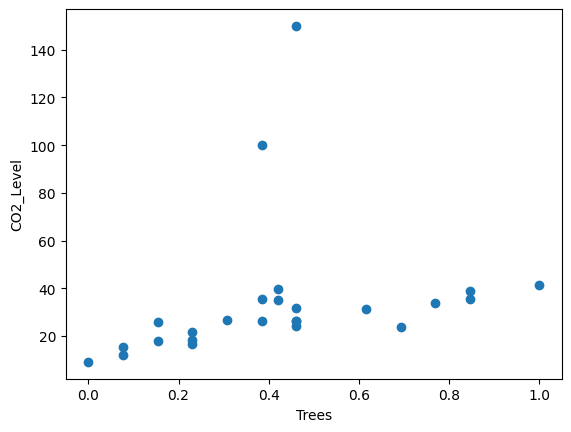

Text(0.5, 1.0, 'Trees Distribution ')

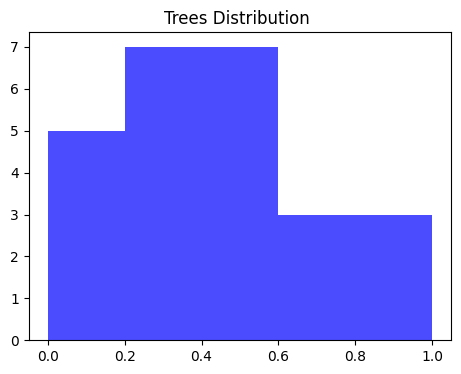

In [ ]:
plt.scatter(clean_data['Trees'], clean_data['CO2_Level'])
plt.xlabel('Trees')
plt.ylabel('CO2_Level')
plt.show()

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(clean_data['Trees'], bins=5, color='blue', alpha=0.7)
plt.title("Trees Distribution ")


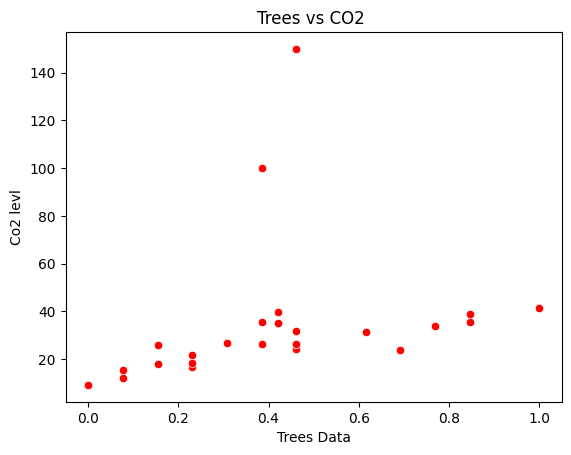

In [ ]:
import seaborn as sns
sns.scatterplot(x='Trees', y='CO2_Level', data=clean_data, color='red')
plt.xlabel('Trees Data')
plt.ylabel('Co2 levl')
plt.title("Trees vs CO2 ")
plt.show()


# **Train the model by using the sklearn library**

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
dataset = clean_data.copy()

In [ ]:

# 1.Creating and Traing the Model
model = LinearRegression() # Created Linear Regression Object
X = dataset[['Trees']] # Giving input Feature, Independent Variable
y = dataset['CO2_Level'] # target --> Dependent Variable

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # spliting the Training=80% and Testing=20% data for model.

model.fit(X_train, y_train) # Training the model



LinearRegression()

In [ ]:
# 2. Make Prediction
y_pred = model.predict(X_test)
y_pred

array([30.8670745 , 23.95151979, 30.8670745 , 33.1722594 , 30.8670745 ])

In [ ]:
n = model.predict([[0.699999999]])
n

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([40.31833257])

In [ ]:
# 3. Evaluate the Model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R-squared:", r2)

Mean Squared Error: 975.0125455938863
R-squared: -0.16874790570888232


In [ ]:
# 4. Print the model Coefficent
print(f"Intercept: {model.intercept_:.2f}")
print(f"Slope: {model.coef_[0]:.2f}")

Intercept: 19.34
Slope: 29.97


Text(0.5, 0, 'Trees')

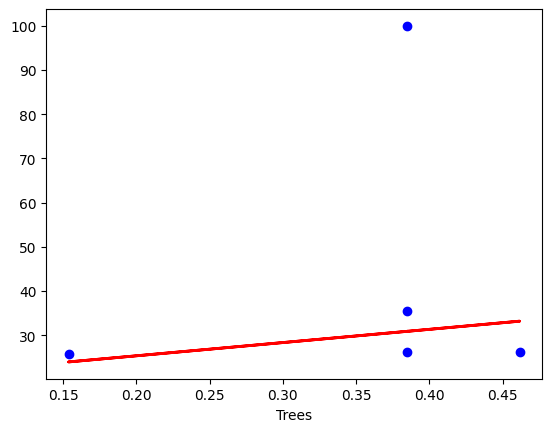

In [ ]:
# 5 Plot Regression Line
plt.scatter(X_test, y_test, color='blue', label='Actual Data')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression Line')
plt.xlabel('Trees')



# Explanation 📚
Data Generation: We created fake data to simulate real-world scenarios.

Preprocessing: Cleaned data by filling missing values, removing outliers, and scaling features.

EDA: Visualized data to understand patterns and relationships.

Math: Calculated slope (m) and intercept (c) using basic statistics.

Model: Plotted the regression line to see how well it fits the data.

Evaluation: Used MSE and R² to measure accuracy.